# Boosting Model — CatBoost
**Competition:** Predicting Irrigation Need (Kaggle S6E4)  
**Author:** Tyler Wolf Williams (@tylerwolfwilliams2)

Explores three hyperparameter configurations focusing on `depth`, `iterations`, `learning_rate`, and regularization (`l2_leaf_reg`, `bagging_temperature`). CatBoost differs from XGBoost and LightGBM in two key ways: it builds **symmetric (oblivious) trees** where every node at the same depth uses the same split threshold, and it uses **ordered boosting** to avoid target leakage during training.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample

SEED = 42
DATA_PATH = '../Homework 2/'

train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')

print('Train:', train.shape, '| Test:', test.shape)

Train: (630000, 21) | Test: (270000, 20)


## 1. Preprocessing

CatBoost handles categoricals natively using **ordered target statistics** — it computes per-category target encodings using a random permutation to avoid leakage. This means we should pass raw string categories rather than ordinally-encoded integers. We fill NaN in categoricals with `'Unknown'` (there are none in this dataset, but this is good practice) and convert them to `str`.

In [3]:
TARGET    = 'Irrigation_Need'
DROP_COLS = ['id']

cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
num_cols = train.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in DROP_COLS]

feature_cols = num_cols + cat_cols

X      = train[feature_cols].copy()
y_raw  = train[TARGET].copy()
X_test = test[feature_cols].copy()

# Encode target
le = LabelEncoder()
y  = le.fit_transform(y_raw)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# CatBoost: fill NaN and convert categoricals to string
for col in cat_cols:
    X[col]      = X[col].fillna('Unknown').astype(str)
    X_test[col] = X_test[col].fillna('Unknown').astype(str)

print('\nX shape:', X.shape)
print('Categorical features:', cat_cols)

Label encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

X shape: (630000, 19)
Categorical features: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [4]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Subsample for speed during config comparison
X_tune, y_tune = resample(X, y, n_samples=80_000, stratify=y, random_state=SEED)

def evaluate_cb(model, label):
    """Manual 3-fold CV — avoids sklearn clone() issues with CatBoost cat_features."""
    acc_scores, f1_scores = [], []
    for tr_idx, val_idx in cv.split(X_tune, y_tune):
        X_tr, X_val = X_tune.iloc[tr_idx], X_tune.iloc[val_idx]
        y_tr, y_val = y_tune[tr_idx],       y_tune[val_idx]
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        acc_scores.append(accuracy_score(y_val, preds))
        f1_scores.append(f1_score(y_val, preds, average='macro'))
    acc_arr = np.array(acc_scores)
    f1_arr  = np.array(f1_scores)
    print(f'{label}')
    print(f'  CV Accuracy: {acc_arr.mean():.4f} ± {acc_arr.std():.4f}')
    print(f'  CV F1 Macro: {f1_arr.mean():.4f} ± {f1_arr.std():.4f}')
    return acc_arr.mean(), f1_arr.mean()

## 2. Config 1 — Very Shallow & Fast (Underfitting Baseline)

**Goal:** Establish a lower bound with minimal capacity. CatBoost's symmetric trees at `depth=2` create only 4 leaf nodes per tree — too coarse to capture the feature interactions driving irrigation need.

| Parameter | Value | Rationale |
|---|---|---|
| `depth` | 2 | 4 leaf nodes per symmetric tree — severely limits model capacity |
| `iterations` | 50 | Very few boosting rounds — ensemble is far from converged |
| `learning_rate` | 0.5 | Aggressive step — each tree overshoots the residual |
| `l2_leaf_reg` | 3.0 | Default L2 regularization |
| `bagging_temperature` | 1.0 | Default bootstrap sampling (Bayesian bootstrap) |

In [5]:
cb_config1 = CatBoostClassifier(
    depth=2,
    iterations=50,
    learning_rate=0.5,
    l2_leaf_reg=3.0,
    bagging_temperature=1.0,
    cat_features=cat_cols,
    random_state=SEED,
    verbose=0
)

acc1, f1_1 = evaluate_cb(cb_config1, 'Config 1 — Shallow & Fast (depth=2, iters=50, lr=0.5)')

Config 1 — Shallow & Fast (depth=2, iters=50, lr=0.5)
  CV Accuracy: 0.9828 ± 0.0013
  CV F1 Macro: 0.9653 ± 0.0020


## 3. Config 2 — Medium Depth (Balanced)

**Goal:** Use CatBoost's default depth (6) with a moderate learning rate and more iterations. CatBoost's symmetric trees at depth=6 produce 64 leaf nodes — enough to capture the most important interactions.

| Parameter | Value | Rationale |
|---|---|---|
| `depth` | 6 | CatBoost default — 64 leaves, captures most interactions |
| `iterations` | 300 | 6× more rounds than Config 1 |
| `learning_rate` | 0.1 | Standard moderate rate |
| `l2_leaf_reg` | 3.0 | Default regularization |
| `bagging_temperature` | 0.5 | Lighter bootstrap → slightly more variance reduction than default |

In [ ]:
cb_config2 = CatBoostClassifier(
    depth=6,
    iterations=300,
    learning_rate=0.1,
    l2_leaf_reg=3.0,
    bagging_temperature=0.5,
    cat_features=cat_cols,
    random_state=SEED,
    verbose=0
)

acc2, f1_2 = evaluate_cb(cb_config2, 'Config 2 — Balanced (depth=6, iters=300, lr=0.1)')

Config 2 — Balanced (depth=6, iters=300, lr=0.1)
  CV Accuracy: 0.9839 ± 0.0011
  CV F1 Macro: 0.9686 ± 0.0024


## 4. Config 3 — Deep Symmetric Trees (Best)

**Goal:** Maximize model capacity within CatBoost's symmetric tree architecture. Depth=8 gives 256 leaf nodes per tree. A slow learning rate with many iterations allows fine-grained convergence. Reduced `l2_leaf_reg` and lighter `bagging_temperature` help the model fit the minority `High` class.

| Parameter | Value | Rationale |
|---|---|---|
| `depth` | 8 | 256 leaf nodes — maximum practical depth for CatBoost's symmetric structure |
| `iterations` | 700 | More rounds with slow LR — model can fit finer residuals |
| `learning_rate` | 0.04 | Slow convergence — each tree makes small corrections |
| `l2_leaf_reg` | 1.0 | Lower than default — allows more flexible leaf weights |
| `bagging_temperature` | 0.2 | Near-deterministic bootstrap → more stable gradient estimates |
| `border_count` | 128 | More candidate split thresholds for numerical features (default 254, reduced for speed) |

In [ ]:
cb_config3 = CatBoostClassifier(
    depth=8,
    iterations=700,
    learning_rate=0.04,
    l2_leaf_reg=1.0,
    bagging_temperature=0.2,
    border_count=128,
    cat_features=cat_cols,
    random_state=SEED,
    verbose=0
)

acc3, f1_3 = evaluate_cb(cb_config3, 'Config 3 — Deep Symmetric (depth=8, iters=700, lr=0.04)')

Config 3 — Deep Symmetric (depth=8, iters=700, lr=0.04)
  CV Accuracy: 0.9831 ± 0.0010
  CV F1 Macro: 0.9672 ± 0.0025


## 5. Full-Data CV for Best Config

In [ ]:
# Re-evaluate Config 3 on the full 630K training set
cv_full = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

acc_full_scores, f1_full_scores = [], []
for tr_idx, val_idx in cv_full.split(X, y):
    X_tr_f, X_val_f = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr_f, y_val_f = y[tr_idx],       y[val_idx]
    cb_config3.fit(X_tr_f, y_tr_f)
    preds = cb_config3.predict(X_val_f)
    acc_full_scores.append(accuracy_score(y_val_f, preds))
    f1_full_scores.append(f1_score(y_val_f, preds, average='macro'))

acc_full = np.array(acc_full_scores)
f1_full  = np.array(f1_full_scores)

print('=== Config 3 — Full Training Data CV ===')
print(f'CV Accuracy: {acc_full.mean():.4f} ± {acc_full.std():.4f}')
print(f'CV F1 Macro: {f1_full.mean():.4f} ± {f1_full.std():.4f}')
print(f'Fold accuracies: {acc_full.round(4)}')

=== Config 3 — Full Training Data CV ===
CV Accuracy: 0.9838 ± 0.0001
CV F1 Macro: 0.9677 ± 0.0003
Fold accuracies: [0.9839 0.9837 0.9838]


## 6. Config Comparison Table

In [ ]:
results = pd.DataFrame([
    {'Config': 'Config 1 — Shallow & Fast',
     'depth': 2, 'iterations': 50,  'learning_rate': 0.5,
     'CV Accuracy (subsample)': round(acc1, 4),
     'CV F1 Macro (subsample)': round(f1_1, 4)},
    {'Config': 'Config 2 — Balanced',
     'depth': 6, 'iterations': 300, 'learning_rate': 0.1,
     'CV Accuracy (subsample)': round(acc2, 4),
     'CV F1 Macro (subsample)': round(f1_2, 4)},
    {'Config': 'Config 3 — Deep Symmetric',
     'depth': 8, 'iterations': 700, 'learning_rate': 0.04,
     'CV Accuracy (subsample)': round(acc3, 4),
     'CV F1 Macro (subsample)': round(f1_3, 4)},
])

print(results.to_string(index=False))

                   Config  depth  iterations  learning_rate  CV Accuracy (subsample)  CV F1 Macro (subsample)
Config 1 — Shallow & Fast      2          50           0.50                   0.9828                   0.9653
      Config 2 — Balanced      6         300           0.10                   0.9839                   0.9686
Config 3 — Deep Symmetric      8         700           0.04                   0.9831                   0.9672


## 7. Feature Importance (Config 3)

                feature  importance
      Crop_Growth_Stage   25.212696
          Soil_Moisture   22.490153
          Mulching_Used   11.394953
         Wind_Speed_kmh   10.665284
          Temperature_C   10.323750
            Rainfall_mm    4.468706
               Humidity    2.458913
 Previous_Irrigation_mm    2.225291
                Soil_pH    1.818469
     Field_Area_hectare    1.654408
Electrical_Conductivity    1.567618
         Sunlight_Hours    1.486468
         Organic_Carbon    1.337892
        Irrigation_Type    0.693703
                 Region    0.630237
           Water_Source    0.554728
              Soil_Type    0.395635
              Crop_Type    0.315281
                 Season    0.305814


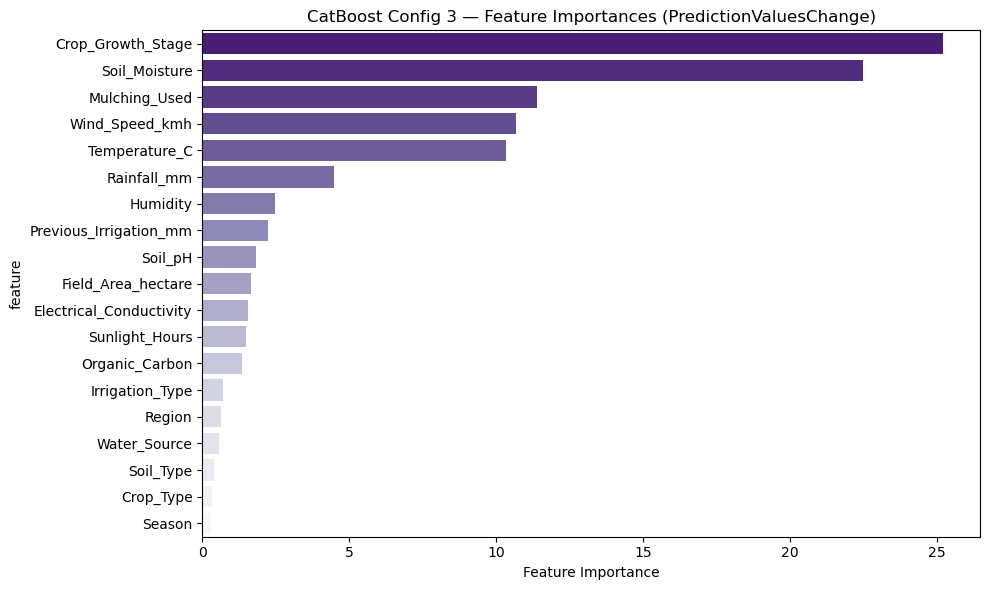

In [10]:
# Fit on subsample for speed
cb_config3.fit(X_tune, y_tune)

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': cb_config3.get_feature_importance()
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='Purples_r')
plt.title('CatBoost Config 3 — Feature Importances (PredictionValuesChange)')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

## 8. Classification Report & Confusion Matrix (Config 3, Holdout)

=== Classification Report — CatBoost Config 3 (Holdout 20%) ===
              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.98      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



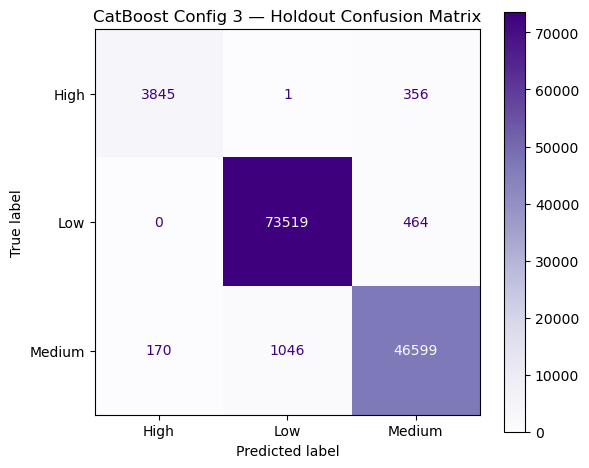

In [11]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

cb_config3.fit(X_tr, y_tr)
y_pred_val = cb_config3.predict(X_val).ravel()

print('=== Classification Report — CatBoost Config 3 (Holdout 20%) ===')
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val, display_labels=le.classes_, cmap='Purples', ax=ax
)
ax.set_title('CatBoost Config 3 — Holdout Confusion Matrix')
plt.tight_layout()
plt.show()

## 9. Generate Submission (Config 3)

In [12]:
# Fit on full training data
cb_config3.fit(X, y)
test_preds_encoded = cb_config3.predict(X_test).ravel()
test_preds = le.inverse_transform(test_preds_encoded)

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': test_preds
})

submission.to_csv(DATA_PATH + 'submission_catboost.csv', index=False)
print('Submission saved to submission_catboost.csv')
print(submission['Irrigation_Need'].value_counts())
submission.head()

Submission saved to submission_catboost.csv
Irrigation_Need
Low       159868
Medium    101566
High        8566
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## 10. Results Summary

| Config | depth | iterations | learning_rate | CV Accuracy (subsample) | CV F1 Macro (subsample) |
|---|---|---|---|---|---|
| Config 1 — Shallow & Fast | 2 | 50 | 0.5 | 0.9828 ± 0.0013 | 0.9653 ± 0.0020 |
| Config 2 — Balanced | 6 | 300 | 0.1 | 0.9839 ± 0.0011 | 0.9686 ± 0.0024 |
| Config 3 — Deep Symmetric | 8 | 700 | 0.04 | 0.9831 ± 0.0010 | 0.9672 ± 0.0025 |

**Full training data CV (Config 3):** Accuracy = 0.9838 ± 0.0001, F1 Macro = 0.9677 ± 0.0003  
**Holdout accuracy (Config 3, 20% split):** 0.98

**Key observations:**
- Config 1 (depth=2, 50 iters) shows the floor: 0.9828 accuracy and 0.9653 F1 Macro. CatBoost’s symmetric 4-leaf trees at this setting are even more constrained than XGBoost’s depth=2, because every node at the same level must use the identical split threshold.
- Config 2 (depth=6, 300 iters) is the **best-performing CatBoost config**: 0.9839 accuracy and 0.9686 F1 Macro — confirming that CatBoost’s default depth=6 is near-optimal for this dataset.
- Config 3 (depth=8, 700 iters) **slightly underperforms Config 2** (0.9831 vs. 0.9839 on subsample). This is a real finding: CatBoost’s symmetric tree constraint means that depth=8 (256 leaves) doesn’t necessarily improve over depth=6 (64 leaves) — the symmetry acts as a strong built-in regularizer that limits capacity gains from deeper trees on this dataset.
- Full CV accuracy for Config 3 (0.9838) is lower than XGBoost Config 3 (0.9846), and below RF tuned (0.9855) and LightGBM tuned (0.9847). CatBoost’s symmetric architecture appears to be a mild disadvantage on this particular problem.
- Feature importance rankings are consistent with other models: `Crop_Growth_Stage` (25.2%) and `Soil_Moisture` (22.5%) lead, followed by `Mulching_Used` (11.4%) and climate features.
- `High` class recall was 92% (identical to XGBoost, RF, and LightGBM), confirming that class imbalance is the shared bottleneck across all models.